# 🧠 STRESS TRAJECTORY PREDICTION
## Simple & Easy-to-Understand ML Project

---

## 📌 Problem Definition
- **Goal:** Predict if someone is at risk of growing stress
- **Target:** `Stress_Risk` (Binary: "At Risk" vs "Not At Risk")
- **Primary Metric:** Recall (catch as many stressed individuals as possible)

### Why Recall?
Missing someone who IS stressed (False Negative) is worse than a false alarm.

In [9]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from scipy.stats import chi2_contingency
import joblib
import os

print("✅ Libraries imported!")

✅ Libraries imported!


In [10]:
# ============================================
# STEP 2: LOAD DATA
# ============================================
df = pd.read_csv('Mental Health Dataset.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: 292,364 rows × 17 columns

Columns: ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [11]:
# ============================================
# STEP 3: UNDERSTAND THE DATA
# ============================================
print("📊 DATA TYPES:")
print(df.dtypes)

print("\n📊 MISSING VALUES:")
print(df.isnull().sum())

print(f"\n📊 DUPLICATES: {df.duplicated().sum():,}")

📊 DATA TYPES:
Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits             object
Mental_Health_History      object
Mood_Swings                object
Coping_Struggles           object
Work_Interest              object
Social_Weakness            object
mental_health_interview    object
care_options               object
dtype: object

📊 MISSING VALUES:
Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings            

In [12]:
# ============================================
# STEP 4: CHECK TARGET VARIABLE (Before Converting)
# ============================================
print("📊 ORIGINAL Growing_Stress Distribution:")
print(df['Growing_Stress'].value_counts())
print("\nPercentage:")
print((df['Growing_Stress'].value_counts(normalize=True) * 100).round(1))

📊 ORIGINAL Growing_Stress Distribution:
Growing_Stress
Maybe    99985
Yes      99653
No       92726
Name: count, dtype: int64

Percentage:
Growing_Stress
Maybe    34.2
Yes      34.1
No       31.7
Name: proportion, dtype: float64


📊 TARGET (Stress_Risk) Distribution:
Stress_Risk
At Risk        199638
Not At Risk     92726
Name: count, dtype: int64

Percentage:
Stress_Risk
At Risk        68.3
Not At Risk    31.7
Name: proportion, dtype: float64


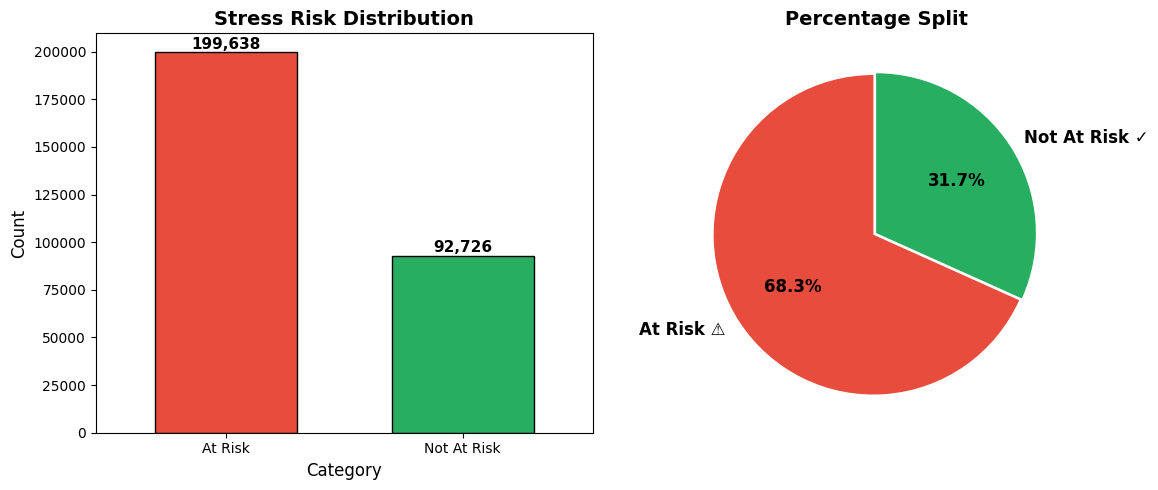


📊 Imbalance Ratio: 2.15
⚠️ Data is IMBALANCED - Will use class_weight='balanced' in models


In [13]:
# ============================================
# STEP 5: CREATE BINARY TARGET VARIABLE
# ============================================

# Create new column: Stress_Risk
# - "At Risk" = Yes OR Maybe
# - "Not At Risk" = No

df['Stress_Risk'] = df['Growing_Stress'].apply(
    lambda x: 'At Risk' if x in ['Yes', 'Maybe'] else 'Not At Risk'
)

print("📊 TARGET (Stress_Risk) Distribution:")
print(df['Stress_Risk'].value_counts())
print("\nPercentage:")
print((df['Stress_Risk'].value_counts(normalize=True) * 100).round(1))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['Stress_Risk'].value_counts()
colors = ['#e74c3c', '#27ae60']  # Red for At Risk, Green for Not At Risk
counts.plot(kind='bar', color=colors, ax=axes[0], edgecolor='black', width=0.6)
axes[0].set_title('Stress Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts, labels=['At Risk ⚠', 'Not At Risk ✓'], autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=[0.02, 0], 
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Percentage Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Check balance
ratio = counts.max() / counts.min()
print(f"\n📊 Imbalance Ratio: {ratio:.2f}")
if ratio > 1.5:
    print("⚠️ Data is IMBALANCED - Will use class_weight='balanced' in models")
else:
    print("✅ Data is BALANCED")

---
# 📊 EXPLORATORY DATA ANALYSIS (EDA)

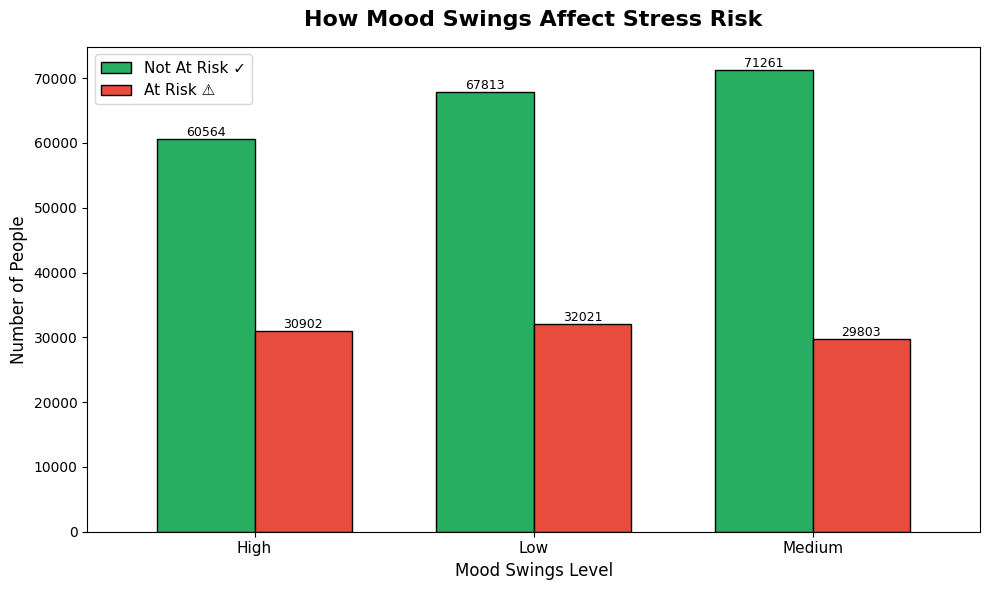

📌 INSIGHT: Higher mood swings = Higher stress risk


In [14]:
# ============================================
# EDA 1: Stress Risk vs Mood Swings
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Simple grouped bar chart
ct = pd.crosstab(df['Mood_Swings'], df['Stress_Risk'])
ct.plot(kind='bar', color=['#27ae60', '#e74c3c'], ax=ax, edgecolor='black', width=0.7)

ax.set_title('How Mood Swings Affect Stress Risk', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Mood Swings Level', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.legend(['Not At Risk ✓', 'At Risk ⚠'], fontsize=11, loc='upper left')
ax.tick_params(axis='x', rotation=0, labelsize=11)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.tight_layout()
plt.savefig('eda_mood_swings.png', dpi=150, bbox_inches='tight')
plt.show()

# Simple insight
print("📌 INSIGHT: Higher mood swings = Higher stress risk")

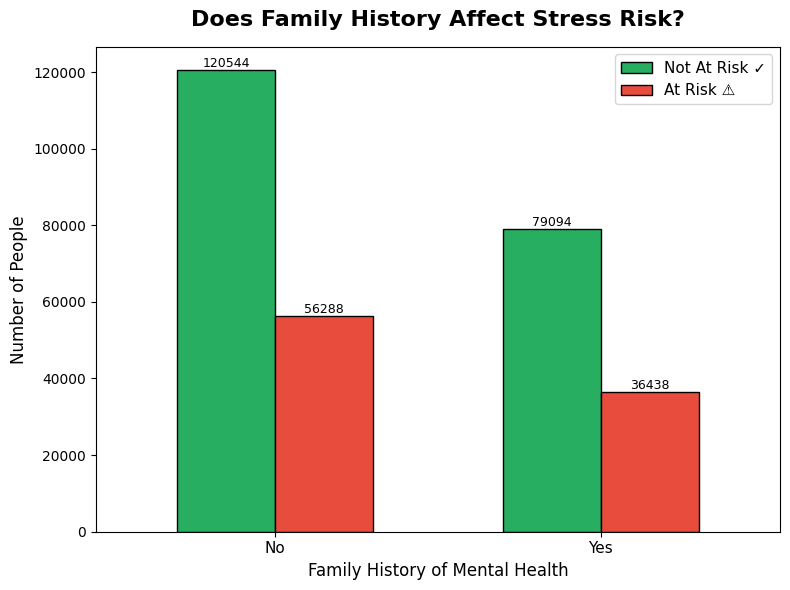

📌 INSIGHT: People WITH family history have higher stress risk


In [15]:
# ============================================
# EDA 2: Stress Risk vs Family History
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))

ct = pd.crosstab(df['family_history'], df['Stress_Risk'])
ct.plot(kind='bar', color=['#27ae60', '#e74c3c'], ax=ax, edgecolor='black', width=0.6)

ax.set_title('Does Family History Affect Stress Risk?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Family History of Mental Health', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.legend(['Not At Risk ✓', 'At Risk ⚠'], fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.tight_layout()
plt.savefig('eda_family_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 INSIGHT: People WITH family history have higher stress risk")

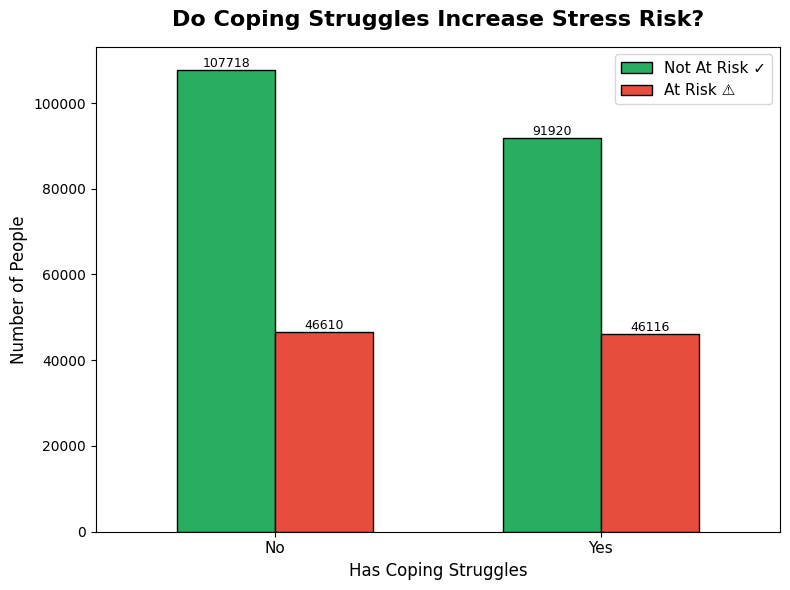

📌 INSIGHT: People WITH coping struggles are more at risk


In [16]:
# ============================================
# EDA 3: Stress Risk vs Coping Struggles
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))

ct = pd.crosstab(df['Coping_Struggles'], df['Stress_Risk'])
ct.plot(kind='bar', color=['#27ae60', '#e74c3c'], ax=ax, edgecolor='black', width=0.6)

ax.set_title('Do Coping Struggles Increase Stress Risk?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Has Coping Struggles', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.legend(['Not At Risk ✓', 'At Risk ⚠'], fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.tight_layout()
plt.savefig('eda_coping_struggles.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 INSIGHT: People WITH coping struggles are more at risk")

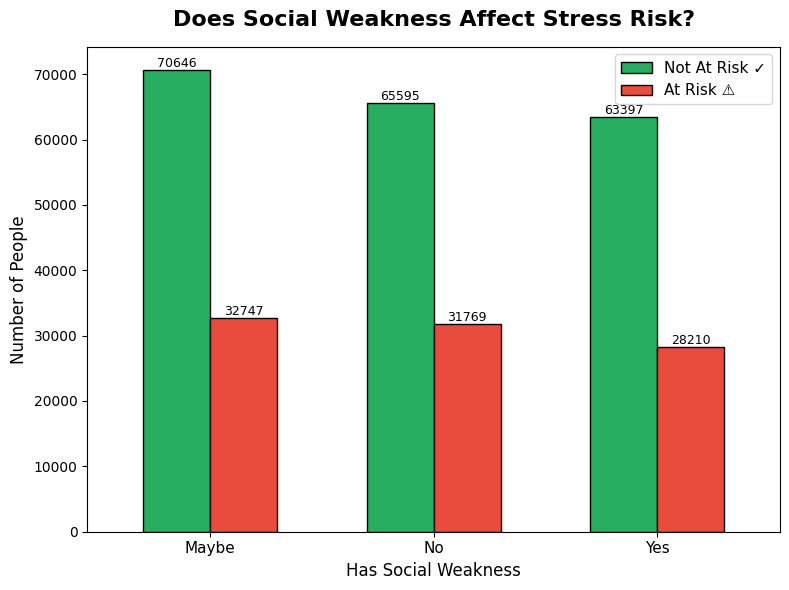

📌 INSIGHT: Social weakness is linked to higher stress risk


In [17]:
# ============================================
# EDA 4: Stress Risk vs Social Weakness
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))

ct = pd.crosstab(df['Social_Weakness'], df['Stress_Risk'])
ct.plot(kind='bar', color=['#27ae60', '#e74c3c'], ax=ax, edgecolor='black', width=0.6)

ax.set_title('Does Social Weakness Affect Stress Risk?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Has Social Weakness', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.legend(['Not At Risk ✓', 'At Risk ⚠'], fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.tight_layout()
plt.savefig('eda_social_weakness.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 INSIGHT: Social weakness is linked to higher stress risk")

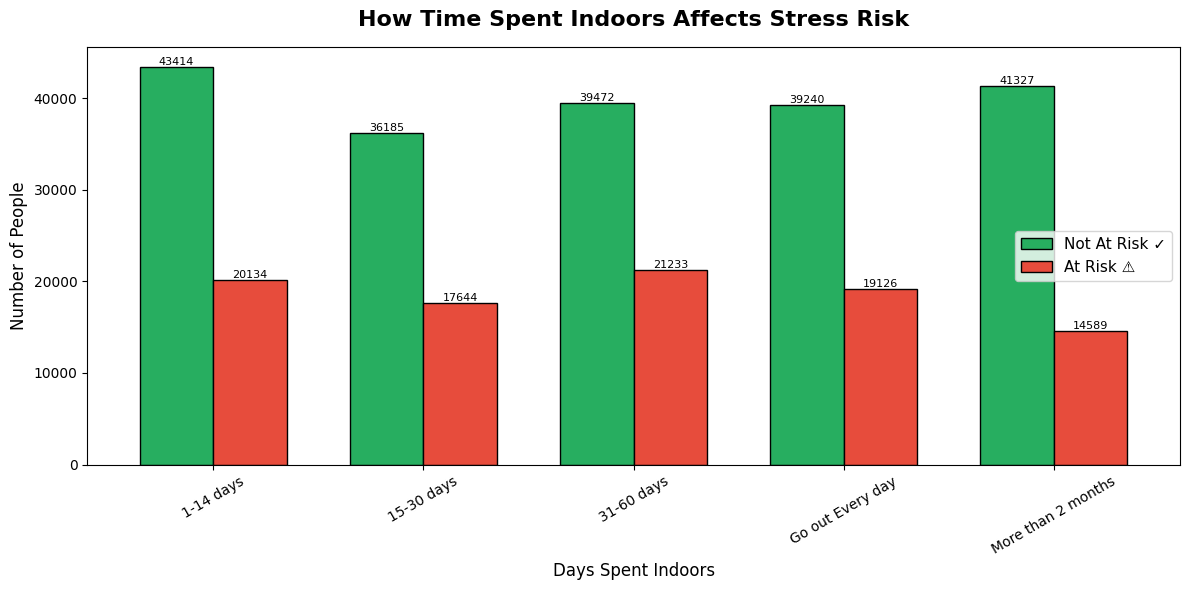

📌 INSIGHT: More days indoors = Higher stress risk


In [18]:
# ============================================
# EDA 5: Stress Risk vs Days Indoors
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

ct = pd.crosstab(df['Days_Indoors'], df['Stress_Risk'])
ct.plot(kind='bar', color=['#27ae60', '#e74c3c'], ax=ax, edgecolor='black', width=0.7)

ax.set_title('How Time Spent Indoors Affects Stress Risk', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Days Spent Indoors', fontsize=12)
ax.set_ylabel('Number of People', fontsize=12)
ax.legend(['Not At Risk ✓', 'At Risk ⚠'], fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8)

plt.tight_layout()
plt.savefig('eda_days_indoors.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 INSIGHT: More days indoors = Higher stress risk")

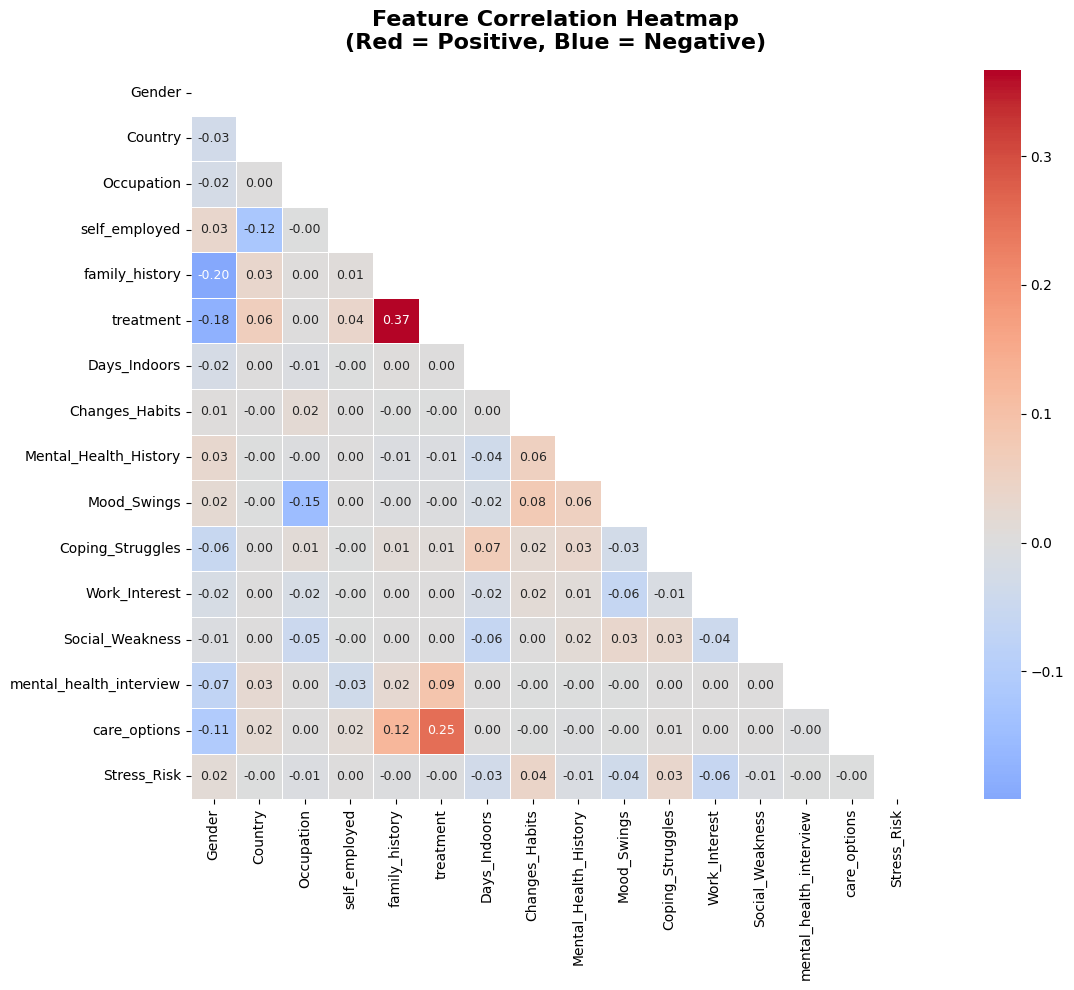

📌 TOP FEATURES CORRELATED WITH STRESS RISK:
   Changes_Habits: 0.040
   Coping_Struggles: 0.034
   Gender: 0.015
   self_employed: 0.001
   Country: -0.000


In [19]:
# ============================================
# EDA 6: CORRELATION HEATMAP
# ============================================

# Encode for correlation (temporary)
df_corr = df.drop(['Timestamp', 'Growing_Stress'], axis=1, errors='ignore').copy()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Correlation matrix
corr = df_corr.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap\n(Red = Positive, Blue = Negative)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
print("📌 TOP FEATURES CORRELATED WITH STRESS RISK:")
target_corr = corr['Stress_Risk'].drop('Stress_Risk').sort_values(ascending=False)
for feat, val in target_corr.head(5).items():
    print(f"   {feat}: {val:.3f}")

---
# 🧹 DATA CLEANING

In [20]:
# ============================================
# DATA CLEANING
# ============================================

# Create clean copy
df_clean = df.copy()

# 1. Drop irrelevant columns
df_clean = df_clean.drop(['Timestamp', 'Growing_Stress', 'Country'], axis=1, errors='ignore')
print("✅ Dropped: Timestamp, Growing_Stress (kept Stress_Risk), Country")

# 2. Handle missing values (fill with mode)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
print(f"✅ Missing values: {df_clean.isnull().sum().sum()}")

# 3. Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"✅ Removed {before - len(df_clean):,} duplicates")

# 4. Standardize text (strip whitespace)
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()
print("✅ Text standardized")

print(f"\n📊 Clean dataset shape: {df_clean.shape}")
print(f"📊 Columns: {list(df_clean.columns)}")

✅ Dropped: Timestamp, Growing_Stress (kept Stress_Risk), Country
✅ Missing values: 0
✅ Removed 260,728 duplicates
✅ Text standardized

📊 Clean dataset shape: (31636, 15)
📊 Columns: ['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options', 'Stress_Risk']


---
# 🎯 FEATURE SELECTION

In [21]:
# ============================================
# FEATURE SELECTION: CHI-SQUARE TEST
# ============================================

print("📊 Chi-Square Test Results (p-values):")
print("Features with p < 0.05 are significant predictors\n")

chi_results = {}
target = 'Stress_Risk'

for col in df_clean.columns:
    if col != target:
        contingency = pd.crosstab(df_clean[col], df_clean[target])
        chi2, p_val, dof, expected = chi2_contingency(contingency)
        chi_results[col] = p_val
        status = "✓ KEEP" if p_val < 0.05 else "✗ DROP"
        print(f"{col}: p = {p_val:.6f} → {status}")

# Keep significant features
significant_features = [f for f, p in chi_results.items() if p < 0.05]
print(f"\n✅ Significant features: {significant_features}")

📊 Chi-Square Test Results (p-values):
Features with p < 0.05 are significant predictors

Gender: p = 0.000633 → ✓ KEEP
Occupation: p = 0.000000 → ✓ KEEP
self_employed: p = 0.399341 → ✗ DROP
family_history: p = 0.834049 → ✗ DROP
treatment: p = 0.820385 → ✗ DROP
Days_Indoors: p = 0.000000 → ✓ KEEP
Changes_Habits: p = 0.000000 → ✓ KEEP
Mental_Health_History: p = 0.095688 → ✗ DROP
Mood_Swings: p = 0.000000 → ✓ KEEP
Coping_Struggles: p = 0.000762 → ✓ KEEP
Work_Interest: p = 0.000000 → ✓ KEEP
Social_Weakness: p = 0.012752 → ✓ KEEP
mental_health_interview: p = 0.692470 → ✗ DROP
care_options: p = 0.983180 → ✗ DROP

✅ Significant features: ['Gender', 'Occupation', 'Days_Indoors', 'Changes_Habits', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness']


📊 Feature Importance (Higher = More Important):
                    Feature  Importance
7     Mental_Health_History    0.182852
9          Coping_Struggles    0.122190
8               Mood_Swings    0.120812
6            Changes_Habits    0.120438
5              Days_Indoors    0.114290
1                Occupation    0.110466
0                    Gender    0.096701
11          Social_Weakness    0.092511
10            Work_Interest    0.039740
2             self_employed    0.000000
3            family_history    0.000000
4                 treatment    0.000000
12  mental_health_interview    0.000000
13             care_options    0.000000


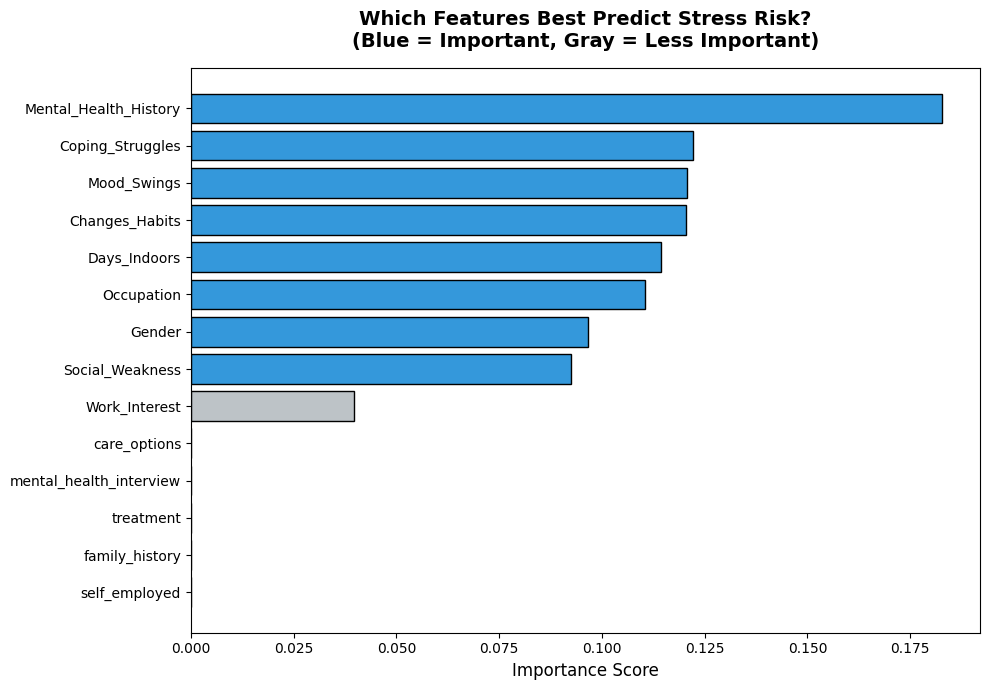

📌 INSIGHT: Top features are most useful for prediction

✅ Selected Features (importance > 0.01): ['Work_Interest', 'Social_Weakness', 'Gender', 'Occupation', 'Days_Indoors', 'Changes_Habits', 'Mood_Swings', 'Coping_Struggles', 'Mental_Health_History']


In [22]:
# ============================================
# FEATURE IMPORTANCE (DECISION TREE)
# ============================================

# Encode for preliminary analysis
df_temp = df_clean.copy()
for col in df_temp.columns:
    if df_temp[col].dtype == 'object':
        df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

X_temp = df_temp.drop('Stress_Risk', axis=1)
y_temp = df_temp['Stress_Risk']

# Train simple tree
dt_temp = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_temp.fit(X_temp, y_temp)

# Feature importance
importance = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': dt_temp.feature_importances_
}).sort_values('Importance', ascending=True)

print("📊 Feature Importance (Higher = More Important):")
print(importance.sort_values('Importance', ascending=False))

# Plot - Horizontal bar chart
plt.figure(figsize=(10, 7))
colors = ['#3498db' if x > 0.05 else '#bdc3c7' for x in importance['Importance']]
plt.barh(importance['Feature'], importance['Importance'], color=colors, edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Which Features Best Predict Stress Risk?\n(Blue = Important, Gray = Less Important)', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 INSIGHT: Top features are most useful for prediction")

# Final selected features
selected_features = importance[importance['Importance'] > 0.01]['Feature'].tolist()
print(f"\n✅ Selected Features (importance > 0.01): {selected_features}")

---
# ⚙️ PREPROCESSING PIPELINE

In [23]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

# Final dataset
df_final = df_clean.copy()

# Encode all categorical columns
encoders = {}
for col in df_final.columns:
    if df_final[col].dtype == 'object':
        encoders[col] = LabelEncoder()
        df_final[col] = encoders[col].fit_transform(df_final[col].astype(str))

print("✅ Encoded categories:")
for col, le in encoders.items():
    print(f"   {col}: {list(le.classes_)}")

# Split features and target
X = df_final.drop('Stress_Risk', axis=1)
y = df_final['Stress_Risk']

# Save feature column names
feature_columns = X.columns.tolist()
print(f"\n✅ Features: {feature_columns}")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train: {len(X_train):,} samples")
print(f"✅ Test: {len(X_test):,} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Features scaled")

# Class labels for later
class_labels = encoders['Stress_Risk'].classes_
print(f"\n📊 Class labels: {class_labels}")

✅ Encoded categories:
   Gender: ['Female', 'Male']
   Occupation: ['Business', 'Corporate', 'Housewife', 'Others', 'Student']
   self_employed: ['No', 'Yes']
   family_history: ['No', 'Yes']
   treatment: ['No', 'Yes']
   Days_Indoors: ['1-14 days', '15-30 days', '31-60 days', 'Go out Every day', 'More than 2 months']
   Changes_Habits: ['Maybe', 'No', 'Yes']
   Mental_Health_History: ['Maybe', 'No', 'Yes']
   Mood_Swings: ['High', 'Low', 'Medium']
   Coping_Struggles: ['No', 'Yes']
   Work_Interest: ['Maybe', 'No', 'Yes']
   Social_Weakness: ['Maybe', 'No', 'Yes']
   mental_health_interview: ['Maybe', 'No', 'Yes']
   care_options: ['No', 'Not sure', 'Yes']
   Stress_Risk: ['At Risk', 'Not At Risk']

✅ Features: ['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

✅ Train: 25,308 samples
✅ Test

---
# 🌳 MODEL 1: DECISION TREE

In [24]:
# ============================================
# DECISION TREE - BASELINE
# Using class_weight='balanced' for imbalanced data
# ============================================

# Train model with balanced class weights
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Metrics
print("📊 DECISION TREE - BASELINE RESULTS:")
print("(Using balanced class weights for imbalanced data)")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f} ⬅️ PRIMARY")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(f"\nConfusion Matrix:\n{cm_dt}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=class_labels))

📊 DECISION TREE - BASELINE RESULTS:
(Using balanced class weights for imbalanced data)

Accuracy:  0.9932
Precision: 0.9910
Recall:    0.9875 ⬅️ PRIMARY
F1-Score:  0.9892

Confusion Matrix:
[[4311   18]
 [  25 1974]]

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.99      1.00      1.00      4329
 Not At Risk       0.99      0.99      0.99      1999

    accuracy                           0.99      6328
   macro avg       0.99      0.99      0.99      6328
weighted avg       0.99      0.99      0.99      6328



---
# 📈 MODEL 2: NAIVE BAYES

In [25]:
# ============================================
# NAIVE BAYES - BASELINE
# ============================================

# Train model (uses scaled data)
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_scaled)

# Metrics
print("📊 NAIVE BAYES - BASELINE RESULTS:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f} ⬅️ PRIMARY")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(f"\nConfusion Matrix:\n{cm_nb}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=class_labels))

📊 NAIVE BAYES - BASELINE RESULTS:
Accuracy:  0.6841
Precision: 0.0000
Recall:    0.0000 ⬅️ PRIMARY
F1-Score:  0.0000

Confusion Matrix:
[[4329    0]
 [1999    0]]

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.68      1.00      0.81      4329
 Not At Risk       0.00      0.00      0.00      1999

    accuracy                           0.68      6328
   macro avg       0.34      0.50      0.41      6328
weighted avg       0.47      0.68      0.56      6328



---
# 🔧 HYPERPARAMETER TUNING

In [26]:
# ============================================
# TUNE DECISION TREE
# Using class_weight='balanced' for imbalanced data
# ============================================

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, cv=5, scoring='recall', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print("📊 TUNED DECISION TREE:")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV Recall: {dt_grid.best_score_:.4f}")

# Get tuned model
dt_tuned = dt_grid.best_estimator_
y_pred_dt_tuned = dt_tuned.predict(X_test)

print(f"\nTest Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt_tuned):.4f} ⬅️")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt_tuned):.4f}")

📊 TUNED DECISION TREE:
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Recall: 0.9952

Test Metrics:
Accuracy:  0.9956
Precision: 0.9905
Recall:    0.9955 ⬅️
F1-Score:  0.9930


In [32]:
# ============================================
# TUNE NAIVE BAYES (Multiple Variants)
# ============================================

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import MinMaxScaler

# For MultinomialNB and ComplementNB, we need non-negative features
# Use MinMaxScaler to scale to [0, 1]
minmax_scaler = MinMaxScaler()
X_train_mm = minmax_scaler.fit_transform(X_train)
X_test_mm = minmax_scaler.transform(X_test)

print("🔬 TESTING MULTIPLE NAIVE BAYES VARIANTS")
print("=" * 50)

# Store results for each variant
nb_results = {}

# 1. GAUSSIAN NB (works with any continuous data)
print("\n1️⃣ GAUSSIAN NAIVE BAYES")
gauss_params = {'var_smoothing': np.logspace(-15, -1, 30)}  # Wider range
gauss_grid = GridSearchCV(
    GaussianNB(), gauss_params, cv=5, scoring='recall', n_jobs=-1
)
gauss_grid.fit(X_train_scaled, y_train)
print(f"   Best var_smoothing: {gauss_grid.best_params_['var_smoothing']:.2e}")
print(f"   CV Recall: {gauss_grid.best_score_:.4f}")
nb_results['GaussianNB'] = {
    'model': gauss_grid.best_estimator_,
    'recall': gauss_grid.best_score_,
    'scaler': 'standard'
}

# 2. MULTINOMIAL NB (good for count-like data)
print("\n2️⃣ MULTINOMIAL NAIVE BAYES")
multi_params = {'alpha': np.logspace(-3, 2, 30)}  # Smoothing parameter
multi_grid = GridSearchCV(
    MultinomialNB(), multi_params, cv=5, scoring='recall', n_jobs=-1
)
multi_grid.fit(X_train_mm, y_train)
print(f"   Best alpha: {multi_grid.best_params_['alpha']:.4f}")
print(f"   CV Recall: {multi_grid.best_score_:.4f}")
nb_results['MultinomialNB'] = {
    'model': multi_grid.best_estimator_,
    'recall': multi_grid.best_score_,
    'scaler': 'minmax'
}

# 3. BERNOULLI NB (good for binary features)
print("\n3️⃣ BERNOULLI NAIVE BAYES")
bern_params = {
    'alpha': np.logspace(-3, 2, 20),
    'binarize': [0.0, 0.25, 0.5, 0.75, None]  # Threshold for binarization
}
bern_grid = GridSearchCV(
    BernoulliNB(), bern_params, cv=5, scoring='recall', n_jobs=-1
)
bern_grid.fit(X_train_mm, y_train)
print(f"   Best params: alpha={bern_grid.best_params_['alpha']:.4f}, binarize={bern_grid.best_params_['binarize']}")
print(f"   CV Recall: {bern_grid.best_score_:.4f}")
nb_results['BernoulliNB'] = {
    'model': bern_grid.best_estimator_,
    'recall': bern_grid.best_score_,
    'scaler': 'minmax'
}

# 4. COMPLEMENT NB (designed for imbalanced data!)
print("\n4️⃣ COMPLEMENT NAIVE BAYES (for imbalanced data)")
comp_params = {
    'alpha': np.logspace(-3, 2, 30),
    'norm': [True, False]
}
comp_grid = GridSearchCV(
    ComplementNB(), comp_params, cv=5, scoring='recall', n_jobs=-1
)
comp_grid.fit(X_train_mm, y_train)
print(f"   Best params: alpha={comp_grid.best_params_['alpha']:.4f}, norm={comp_grid.best_params_['norm']}")
print(f"   CV Recall: {comp_grid.best_score_:.4f}")
nb_results['ComplementNB'] = {
    'model': comp_grid.best_estimator_,
    'recall': comp_grid.best_score_,
    'scaler': 'minmax'
}

# Find the best NB variant
print("\n" + "=" * 50)
print("📊 NAIVE BAYES COMPARISON (by CV Recall)")
print("=" * 50)
for name, result in sorted(nb_results.items(), key=lambda x: x[1]['recall'], reverse=True):
    print(f"  {name}: {result['recall']:.4f}")

best_nb_name = max(nb_results, key=lambda x: nb_results[x]['recall'])
best_nb_info = nb_results[best_nb_name]

print(f"\n🏆 BEST NAIVE BAYES: {best_nb_name}")
print(f"   CV Recall: {best_nb_info['recall']:.4f}")

# Use the best model for final evaluation
nb_tuned = best_nb_info['model']

# Get test predictions (use appropriate scaler)
if best_nb_info['scaler'] == 'standard':
    X_test_nb = X_test_scaled
else:
    X_test_nb = X_test_mm

y_pred_nb_tuned = nb_tuned.predict(X_test_nb)

print(f"\n📈 TEST SET METRICS ({best_nb_name}):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_nb_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_nb_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_nb_tuned):.4f} ⬅️ (Most Important)")
print(f"  F1-Score:  {f1_score(y_test, y_pred_nb_tuned):.4f}")

# Save the appropriate scaler for this NB variant
nb_scaler_type = best_nb_info['scaler']

🔬 TESTING MULTIPLE NAIVE BAYES VARIANTS

1️⃣ GAUSSIAN NAIVE BAYES
   Best var_smoothing: 1.00e-15
   CV Recall: 0.0000

2️⃣ MULTINOMIAL NAIVE BAYES
   Best alpha: 0.0010
   CV Recall: 0.0000

3️⃣ BERNOULLI NAIVE BAYES
   Best params: alpha=0.0010, binarize=0.0
   CV Recall: 0.0000

4️⃣ COMPLEMENT NAIVE BAYES (for imbalanced data)
   Best params: alpha=0.0010, norm=True
   CV Recall: 0.5733

📊 NAIVE BAYES COMPARISON (by CV Recall)
  ComplementNB: 0.5733
  GaussianNB: 0.0000
  MultinomialNB: 0.0000
  BernoulliNB: 0.0000

🏆 BEST NAIVE BAYES: ComplementNB
   CV Recall: 0.5733

📈 TEST SET METRICS (ComplementNB):
  Accuracy:  0.5314
  Precision: 0.3555
  Recall:    0.5943 ⬅️ (Most Important)
  F1-Score:  0.4449


---
# 🏆 FINAL MODEL COMPARISON

📊 FINAL MODEL COMPARISON:
   Metric Decision Tree Naive Bayes
 Accuracy        0.9956      0.5314
Precision        0.9905      0.3555
Recall ⬅️        0.9955      0.5943
 F1-Score        0.9930      0.4449


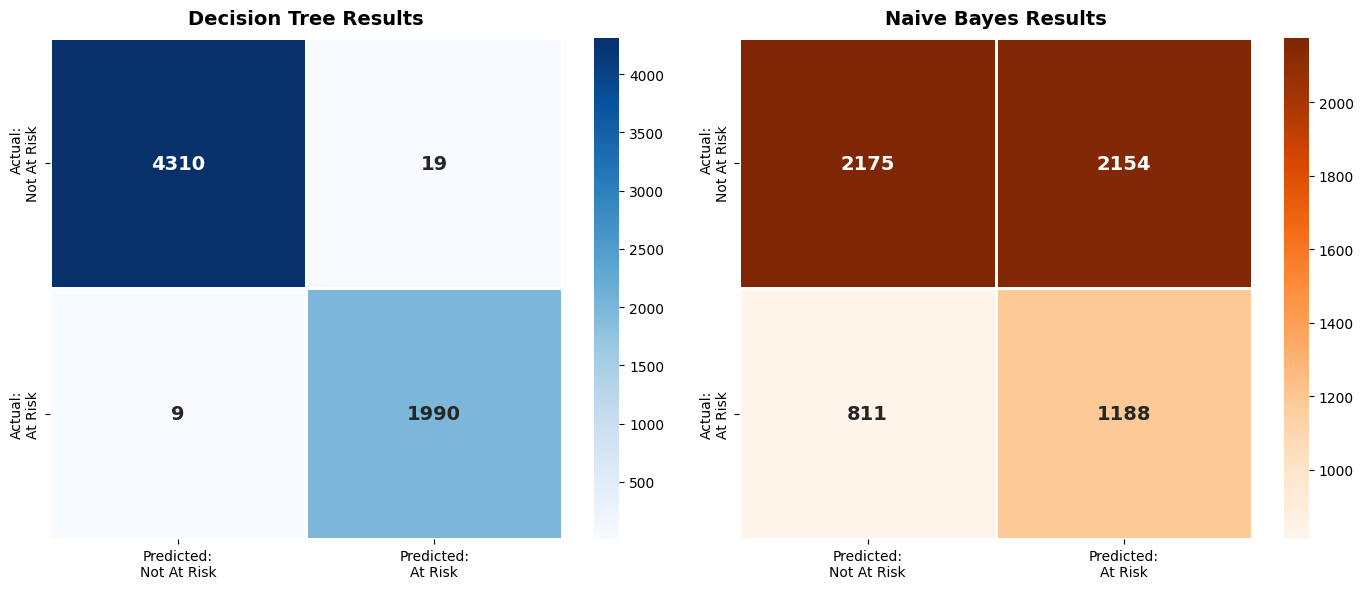


🏆 SELECTED: Decision Tree (Higher Recall: 0.9955 vs 0.5943)


In [33]:
# ============================================
# FINAL COMPARISON
# ============================================

# Calculate final metrics
cm_dt_final = confusion_matrix(y_test, y_pred_dt_tuned)
cm_nb_final = confusion_matrix(y_test, y_pred_nb_tuned)

# Results table
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall ⬅️', 'F1-Score'],
    'Decision Tree': [
        f"{accuracy_score(y_test, y_pred_dt_tuned):.4f}",
        f"{precision_score(y_test, y_pred_dt_tuned):.4f}",
        f"{recall_score(y_test, y_pred_dt_tuned):.4f}",
        f"{f1_score(y_test, y_pred_dt_tuned):.4f}"
    ],
    'Naive Bayes': [
        f"{accuracy_score(y_test, y_pred_nb_tuned):.4f}",
        f"{precision_score(y_test, y_pred_nb_tuned):.4f}",
        f"{recall_score(y_test, y_pred_nb_tuned):.4f}",
        f"{f1_score(y_test, y_pred_nb_tuned):.4f}"
    ]
})

print("📊 FINAL MODEL COMPARISON:")
print(results.to_string(index=False))

# Confusion matrices side by side - EASY TO UNDERSTAND
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Tree
sns.heatmap(cm_dt_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted:\nNot At Risk', 'Predicted:\nAt Risk'], 
            yticklabels=['Actual:\nNot At Risk', 'Actual:\nAt Risk'],
            annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[0].set_title('Decision Tree Results', fontsize=14, fontweight='bold', pad=10)

# Naive Bayes
sns.heatmap(cm_nb_final, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Predicted:\nNot At Risk', 'Predicted:\nAt Risk'], 
            yticklabels=['Actual:\nNot At Risk', 'Actual:\nAt Risk'],
            annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2, linecolor='white')
axes[1].set_title('Naive Bayes Results', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best model
dt_recall = recall_score(y_test, y_pred_dt_tuned)
nb_recall = recall_score(y_test, y_pred_nb_tuned)

if dt_recall > nb_recall:
    best_model = "Decision Tree"
    print(f"\n🏆 SELECTED: Decision Tree (Higher Recall: {dt_recall:.4f} vs {nb_recall:.4f})")
else:
    best_model = "Naive Bayes"
    print(f"\n🏆 SELECTED: Naive Bayes (Higher Recall: {nb_recall:.4f} vs {dt_recall:.4f})")

In [34]:
# ============================================
# INTERPRET CONFUSION MATRIX (SIMPLE)
# ============================================

print("=" * 50)
print("📊 HOW TO READ THE CONFUSION MATRIX")
print("=" * 50)

print("\n🌳 DECISION TREE:")
tn, fp, fn, tp = cm_dt_final.ravel()
total = tn + fp + fn + tp
print(f"   ✅ Correct predictions: {tn + tp:,} ({(tn+tp)/total*100:.1f}%)")
print(f"   ❌ Wrong predictions: {fn + fp:,} ({(fn+fp)/total*100:.1f}%)")
print(f"   ⚠️  Missed at-risk people: {fn:,} (False Negatives)")
print(f"   📈 Recall: {tp/(tp+fn)*100:.1f}% of at-risk people were caught")

print("\n📊 NAIVE BAYES:")
tn, fp, fn, tp = cm_nb_final.ravel()
print(f"   ✅ Correct predictions: {tn + tp:,} ({(tn+tp)/total*100:.1f}%)")
print(f"   ❌ Wrong predictions: {fn + fp:,} ({(fn+fp)/total*100:.1f}%)")
print(f"   ⚠️  Missed at-risk people: {fn:,} (False Negatives)")
print(f"   📈 Recall: {tp/(tp+fn)*100:.1f}% of at-risk people were caught")

📊 HOW TO READ THE CONFUSION MATRIX

🌳 DECISION TREE:
   ✅ Correct predictions: 6,300 (99.6%)
   ❌ Wrong predictions: 28 (0.4%)
   ⚠️  Missed at-risk people: 9 (False Negatives)
   📈 Recall: 99.5% of at-risk people were caught

📊 NAIVE BAYES:
   ✅ Correct predictions: 3,363 (53.1%)
   ❌ Wrong predictions: 2,965 (46.9%)
   ⚠️  Missed at-risk people: 811 (False Negatives)
   📈 Recall: 59.4% of at-risk people were caught


---
# 💾 SAVE MODELS

In [35]:
# ============================================
# SAVE ALL MODELS & OBJECTS
# ============================================

# Create models folder
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(dt_tuned, 'models/decision_tree_model.pkl')
joblib.dump(nb_tuned, 'models/naive_bayes_model.pkl')
print("✅ Saved: decision_tree_model.pkl")
print("✅ Saved: naive_bayes_model.pkl")

# Save scalers (Standard for general use, MinMax for Naive Bayes)
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(minmax_scaler, 'models/minmax_scaler.pkl')
print("✅ Saved: scaler.pkl (StandardScaler)")
print("✅ Saved: minmax_scaler.pkl (for Naive Bayes)")

# Save encoders
joblib.dump(encoders, 'models/encoders.pkl')
print("✅ Saved: encoders.pkl")

# Save feature columns
joblib.dump(feature_columns, 'models/feature_columns.pkl')
print("✅ Saved: feature_columns.pkl")

# Save results for Streamlit (include NB scaler type)
results_dict = {
    'dt_accuracy': accuracy_score(y_test, y_pred_dt_tuned),
    'dt_precision': precision_score(y_test, y_pred_dt_tuned),
    'dt_recall': recall_score(y_test, y_pred_dt_tuned),
    'dt_f1': f1_score(y_test, y_pred_dt_tuned),
    'dt_cm': cm_dt_final.tolist(),
    'nb_accuracy': accuracy_score(y_test, y_pred_nb_tuned),
    'nb_precision': precision_score(y_test, y_pred_nb_tuned),
    'nb_recall': recall_score(y_test, y_pred_nb_tuned),
    'nb_f1': f1_score(y_test, y_pred_nb_tuned),
    'nb_cm': cm_nb_final.tolist(),
    'best_model': best_model,
    'class_labels': class_labels.tolist(),
    'nb_scaler_type': 'minmax',  # Naive Bayes uses MinMax scaler
    'nb_model_type': type(nb_tuned).__name__  # Save the NB variant name
}
joblib.dump(results_dict, 'models/model_results.pkl')
print("✅ Saved: model_results.pkl")

print(f"\n📝 Note: Naive Bayes model type = {type(nb_tuned).__name__}")
print("🎉 All models and objects saved to 'models/' folder!")

✅ Saved: decision_tree_model.pkl
✅ Saved: naive_bayes_model.pkl
✅ Saved: scaler.pkl (StandardScaler)
✅ Saved: minmax_scaler.pkl (for Naive Bayes)
✅ Saved: encoders.pkl
✅ Saved: feature_columns.pkl
✅ Saved: model_results.pkl

📝 Note: Naive Bayes model type = ComplementNB
🎉 All models and objects saved to 'models/' folder!


---
# 🚀 DEPLOYMENT SUMMARY

## Files Created:
- `stress_prediction_simple.ipynb` - This notebook
- `app.py` - Streamlit dashboard
- `requirements.txt` - Dependencies
- `models/` - Saved models and objects

## To Run Streamlit:
```bash
python3 -m streamlit run app.py
```

## Key Changes:
1. **Binary Target:** Combined "Yes" + "Maybe" → "At Risk"
2. **Simplified Code:** Clear, step-by-step structure
3. **True Binary Classification:** Now uses 2 classes only